In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-course-reproduction.ZfVaEu/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-course-reproduction.ZfVaEu/venv", "python": "3.12.14", "torch_cuda_build": null}


# Baselines: expectation, variance, and self-inclusion

Day 20 · Chapter 12. CPU, authored synthetic data, no downloads. Predict before each reference, change one declared variable, and interpret the result. Code is complete so the notebook runs from beginning to end. Completing its execution is material verification, not an assessment of learner mastery.

[Canonical chapter](../../book/chapters/12-language-generation-as-a-policy.md)


In [2]:
from pathlib import Path
import sys
root = Path.cwd().resolve()
while not (root / "src" / "dongxi_llms").is_dir():
    if root.parent == root:
        raise RuntimeError("Open this notebook within the Dongxi_LLMs repository")
    root = root.parent
sys.path.insert(0, str(root / "src"))
import torch
import matplotlib.pyplot as plt
torch.set_num_threads(1)
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "font.family": "DejaVu Sans", "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
blue, orange, green = "#356a9b", "#b97139", "#3d8268"



## Exercise 1: choose a baseline

Does every action-independent baseline reduce variance? Predict what baseline 8 will do compared with 0 and 1.3. Each expectation below is exactly enumerated.


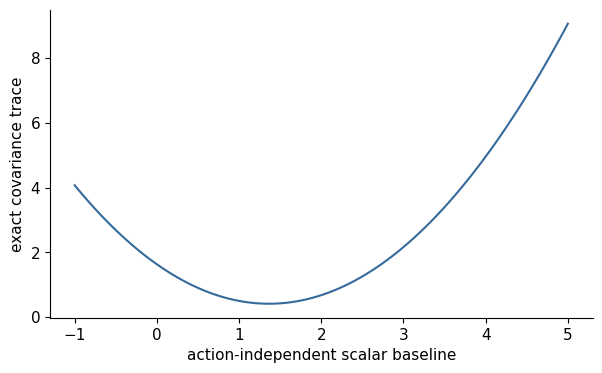

0.0 1.6320410932074991
1.3 0.4183253278665062
8.0 29.189494731245837


In [3]:
from dongxi_llms.policy_gradient_lab import exact_gradient,estimator_moments,group_estimator_moments,rloo_advantages
logits=torch.tensor([.3,-.2,.1],dtype=torch.float64)
reward=torch.tensor([0.,1.,3.],dtype=torch.float64)
expected=exact_gradient(logits,reward)
baselines=torch.linspace(-1,5,121,dtype=torch.float64)
variances=[estimator_moments(logits,reward,float(b))["variance_trace"] for b in baselines]
fig,ax=plt.subplots(figsize=(7,4));ax.plot(baselines,variances,color=blue)
ax.set(xlabel="action-independent scalar baseline",ylabel="exact covariance trace");plt.show()
for b in (0.,1.3,8.):
    result=estimator_moments(logits,reward,b)
    torch.testing.assert_close(result["mean"],expected)
    print(b,result["variance_trace"])


![Saved reference plot for 01 baselines and rloo, figure 1](../figures/chapter-12/day-20-01_baselines_and_rloo-01.png)

Saved reference output from the verified CPU run. Run the preceding cell to regenerate the current experiment; this image does not change when parameters are edited.


**Solution:** action independence preserves the mean, but an inaccurate baseline can increase variance. The minimum need not occur at expected reward because score-vector norms weight actions differently.

## Exercise 2: leave out the current sample

For G=3 iid samples, predict whether inclusive mean centering and leave-one-out centering have the same expected gradient.


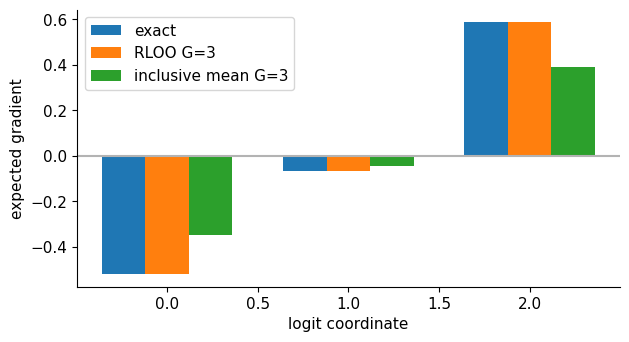

{'rloo_variance': 0.42846428797227315, 'inclusive_variance': 0.19042857243212144}


In [4]:
rloo=group_estimator_moments(logits,reward,group=3)
inclusive=group_estimator_moments(logits,reward,group=3,leave_one_out=False)
torch.testing.assert_close(rloo["mean"],expected)
torch.testing.assert_close(inclusive["mean"],expected*2/3)
fig,ax=plt.subplots(figsize=(7,3.6))
x=torch.arange(3).numpy()
for offset,values,label in ((-.24,expected,"exact"),(0,rloo["mean"],"RLOO G=3"),(.24,inclusive["mean"],"inclusive mean G=3")):
    ax.bar(x+offset,values,width=.24,label=label)
ax.axhline(0,color=".7");ax.set(xlabel="logit coordinate",ylabel="expected gradient");ax.legend();plt.show()
print({"rloo_variance":rloo["variance_trace"],"inclusive_variance":inclusive["variance_trace"]})


![Saved reference plot for 01 baselines and rloo, figure 2](../figures/chapter-12/day-20-01_baselines_and_rloo-02.png)

Saved reference output from the verified CPU run. Run the preceding cell to regenerate the current experiment; this image does not change when parameters are edited.


**Read the figure:** RLOO matches the exact mean. Inclusive centering scales it by two thirds; its smaller variance must be interpreted with that altered mean. Scaling it back restores the same leave-one-out estimator.

## Exercise 3: zero advantages and a biased baseline

Can a group have zero signal even though the population rewards differ? What happens if the baseline is the sampled reward itself?


In [5]:
equal_group=torch.tensor([1.,1.,1.],dtype=torch.float64)
torch.testing.assert_close(rloo_advantages(equal_group),torch.zeros_like(equal_group))
example=torch.tensor([0.,1.,3.],dtype=torch.float64)
loo=rloo_advantages(example)
inclusive=example-example.mean()
torch.testing.assert_close(inclusive,loo*2/3)
print({"equal_group_advantage":rloo_advantages(equal_group).tolist(),
       "different_group_advantage":loo.tolist(),
       "reward_itself_as_baseline":[0.,0.,0.],
       "nonzero_population_gradient":expected.tolist()})


{'equal_group_advantage': [0.0, 0.0, 0.0], 'different_group_advantage': [-2.0, -0.5, 2.5], 'reward_itself_as_baseline': [0.0, 0.0, 0.0], 'nonzero_population_gradient': [-0.5207036170854552, -0.06573393176389039, 0.5864375488493454]}


**Solution:** a particular group can contain no reward variation and provide zero RLOO update, while other groups retain learning signal. A baseline equal to the same sampled reward is action-dependent and destroys the expected gradient. Detaching its tensor cannot repair the statistical dependence.

**Evidence boundary:** iid sampling conditional on a shared prompt is required. Copied completions, coupled diversity sampling, or mixing different prompts break this proof. Random standard-deviation normalization requires separate bias analysis.
